In [1]:
# Colab: 挂载 Google Drive（已挂载则跳过）
import os

if os.path.exists("/content"):
    from google.colab import drive

    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
    else:
        print("Drive already mounted.")
else:
    print("Non-Colab environment, skip Drive mount.")

Non-Colab environment, skip Drive mount.


In [2]:
import json
import os
import sys
from pathlib import Path

# 可切换数据集名称（需与 course project 下目录名一致）
DATA_NAME = "SLEEP"

# 可选：手动指定数据根目录（留空则自动探测）
# 例如：DATA_ROOT_OVERRIDE = Path("/content/drive/MyDrive/新建文件夹/course project")
DATA_ROOT_OVERRIDE = Path("D:/ML_project/data/course project")


def resolve_data_root():
    # 1) 显式覆盖优先
    if DATA_ROOT_OVERRIDE is not None:
        return Path(DATA_ROOT_OVERRIDE)

    # 2) 环境变量（便于 Cursor/Colab 插件配置）
    env_root = os.environ.get("EEG_DATA_ROOT")
    if env_root:
        p = Path(env_root)
        if p.exists():
            return p

    # 3) 自动探测常见路径（本地 + Colab）
    # 以 notebook 所在目录为锚点，向上/下搜索
    _notebook_dir = Path.cwd()  # fallback
    try:
        import ipykernel
        _kernel_path = Path(ipykernel.get_connection_file())
        # 从 kernel 回溯到 notebook 目录
        if ".local" in str(_kernel_path):
            _notebook_dir = Path.cwd()
    except Exception:
        _notebook_dir = Path.cwd()

    candidates = [
        # 本地：notebook 在 project root
        Path.cwd() / "data" / "course project",
        # 本地：notebook 在 project/notebooks/
        Path.cwd().parent / "data" / "course project",
        # 直接从 ML_project 根目录
        Path.cwd() / ".." / "data" / "course project",
        # 绝对路径兜底（当前项目结构）
        Path("D:/ML_project/data/course project"),
        # Colab 路径
        Path("/content/course project"),
        Path("/content/drive/MyDrive/course project"),
        Path("/content/drive/MyDrive/新建文件夹/course project"),
    ]
    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(
        "Cannot locate dataset root. Set DATA_ROOT_OVERRIDE or env EEG_DATA_ROOT."
    )


DATA_ROOT = resolve_data_root()

# 将 src/ 加入 Python 路径，使 import RNN/TEST_DATASET 可用
_src_candidates = [
    Path.cwd() / "src",
    Path.cwd().parent / "src",
]
for _p in _src_candidates:
    if (_p / "RNN.py").exists() or (_p / "__init__.py").exists():
        sys.path.insert(0, str(_p))
        print(f"Source dir: {_p}")
        break


# Colab 下可选：先把当前数据集复制到 /content 本地盘，加速训练
USE_LOCAL_CONTENT_CACHE = True
if USE_LOCAL_CONTENT_CACHE and Path("/content").exists():
    import shutil

    src_base_dir = DATA_ROOT / DATA_NAME
    dst_base_dir = Path("/content/course project") / DATA_NAME
    dst_base_dir.mkdir(parents=True, exist_ok=True)

    files_to_copy = [
        "train.h5",
        "val.h5",
        "test_x_only.h5",
        "dataset_info.json",
        "dataset_info_fixed.json",
    ]

    copied_any = False
    for fn in files_to_copy:
        src = src_base_dir / fn
        dst = dst_base_dir / fn
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
            copied_any = True
            print(f"Copied to local cache: {src} -> {dst}")

    if copied_any:
        print(f"Using local cached dataset at: {dst_base_dir}")
    else:
        print(f"Local cache already present or source files missing: {dst_base_dir}")

    DATA_ROOT = Path("/content/course project")

# ========== 输出根目录 ==========
# 所有训练结果统一保存到 results/{数据集}/{模型名}/{实验名}/ 下
# 具体子目录结构在训练格（Cell 14）中创建
_res_candidates = [
    Path.cwd() / "results",
    Path.cwd().parent / "results",
]
RESULTS_DIR = next((p for p in _res_candidates if p.exists()), Path.cwd().parent / "results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results dir: {RESULTS_DIR}")

BASE_DIR = DATA_ROOT / DATA_NAME

# 兼容不同数据集的元信息文件命名
candidate_info_paths = [
    BASE_DIR / "dataset_info.json",
    BASE_DIR / "dataset_info_fixed.json",
]
DATA_INFO_PATH = next((p for p in candidate_info_paths if p.exists()), None)
if DATA_INFO_PATH is None:
    raise FileNotFoundError(
        f"No dataset info json found under {BASE_DIR}. "
        f"Tried: {[str(p) for p in candidate_info_paths]}"
    )

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Dataset:", DATA_NAME)
print("Data root:", DATA_ROOT)
print("Data dir:", BASE_DIR)
print("Info file:", DATA_INFO_PATH.name)
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)


=== Dataset Intro ===
Dataset: SLEEP
Data root: c:\Users\29722\Desktop\新建文件夹\course project
Data dir: c:\Users\29722\Desktop\新建文件夹\course project\SLEEP
Info file: dataset_info.json
Categories: ['Wake', 'N1', 'N2', 'N3', 'REM']
Channels (count): 6
Channels: ['C3_A2', 'C4_A1', 'F3_A2', 'F4_A1', 'O1_A2', 'O2_A1']
Target Sampling Rate (Hz): 200.0
Window Size (sec): 30.0


In [3]:
# 已在最前面的挂载单元处理，这里无需重复挂载
print("Drive mount is handled in the first cell.")

Drive mount is handled in the first cell.


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [4]:
import h5py
import numpy as np

INDEX_PATH_TRAIN = BASE_DIR / "train.h5"
INDEX_PATH_VAL = BASE_DIR / "val.h5"
INDEX_PATH_TEST = BASE_DIR / "test_x_only.h5"

required_files = [INDEX_PATH_TRAIN, INDEX_PATH_VAL, INDEX_PATH_TEST]
missing_files = [p for p in required_files if not p.exists()]
if missing_files:
    existing = sorted([p.name for p in BASE_DIR.glob("*")]) if BASE_DIR.exists() else []
    raise FileNotFoundError(
        f"Missing files: {[str(p) for p in missing_files]}\n"
        f"BASE_DIR exists: {BASE_DIR.exists()}\n"
        f"BASE_DIR: {BASE_DIR}\n"
        f"Existing files under BASE_DIR: {existing}"
    )

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

keys: ['X', 'y']
x dtype: float32
x shape: (3921, 6, 6000)
y dtype: int64
y shape: (3921,)
unique: [0 1 2 3 4]


## 2) 定义模型：SimpleLinear
最简单的线性分类器，方便和更复杂模型对比。


In [5]:
import torch
import torch.nn as nn

class SimpleLinear(nn.Module):
    def __init__(self, input_channels, time_points, num_classes):
        super(SimpleLinear, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_channels * time_points, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)


## 3) 定义模型：SimpleMLP
把输入拉平后通过多层全连接网络进行分类，表达能力比线性模型更强。


In [6]:
class SimpleMLP(nn.Module):
    def __init__(
        self,
        input_channels,
        num_classes=2,
        time_points=200,
        hidden_dims=(256, 128),
        dropout=0.3
    ):
        super().__init__()

        input_dim = input_channels * time_points

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))

        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, C, T)
        x = self.flatten(x)      # -> (B, C*T)
        logits = self.mlp(x)     # -> (B, num_classes)
        return logits

## 4) 定义模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline


In [7]:
class EEGNet(nn.Module):  # EEGNet-8,2
    def __init__(
        self,
        chans,
        time_point,
        num_classes,
        f1=8,
        d=2,
        pk1=4,
        pk2=8,
        dp=0.5,
        max_norm1=1,
        norm=torch.nn.Identity(),
    ):
        super().__init__()
        f2 = f1 * d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(f1),
        )
        # Spatial Filters
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),  # Depthwise Conv
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding=(0, 8)),  # Separable Conv
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),  # Pointwise Conv
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp),
        )

        self._apply_max_norm(self.block2[0], max_norm1)
        self.embed_dim = f2 * ((time_point // pk1) // pk2)
        self.classifier = nn.Linear(self.embed_dim, num_classes)
        self.norm = norm

    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if "weight" in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        x = self.norm(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(dim=1)
        x = self.block1(x.unsqueeze(dim=1))
        x = self.block2(x)
        x = self.block3(x)
        feat = x.flatten(start_dim=1)
        logits = self.classifier(feat)
        return logits

## 5) 导入模型：EEGGRU
这里希望同学们自己手搓一个RNN代码，试试RNN的训练效果如何


In [8]:
import sys
from pathlib import Path

# 自动搜索 RNN.py（兼容本地与 Colab/Drive）
search_dirs = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "course project",
    Path("/content"),
    Path("/content/drive/MyDrive"),
    Path("/content/drive/MyDrive/新建文件夹"),
    Path("/content/drive/MyDrive/新建文件夹/course project"),
]

rnn_path = None
for d in search_dirs:
    p = d / "RNN.py"
    if p.exists():
        rnn_path = p
        break

if rnn_path is None:
    raise FileNotFoundError(
        "RNN.py not found. Please upload/sync RNN.py to your runtime-accessible project path."
    )

rnn_dir = str(rnn_path.parent)
if rnn_dir not in sys.path:
    sys.path.append(rnn_dir)

from RNN import EEGGRU
print(f"Loaded EEGGRU from: {rnn_path}")

Loaded EEGGRU from: c:\Users\29722\Desktop\新建文件夹\RNN.py


## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


Model: EEGNet
Model input shape set to: (C=6, T=6000)
Epoch [01/20] | Train Loss: 1.6155 | Val Loss: 1.6024 | Val Acc: 0.2354
Epoch [02/20] | Train Loss: 1.5990 | Val Loss: 1.5866 | Val Acc: 0.2427
Epoch [03/20] | Train Loss: 1.5759 | Val Loss: 1.5734 | Val Acc: 0.2674
Epoch [04/20] | Train Loss: 1.5491 | Val Loss: 1.5591 | Val Acc: 0.2813
Epoch [05/20] | Train Loss: 1.5224 | Val Loss: 1.5437 | Val Acc: 0.2926
Epoch [06/20] | Train Loss: 1.4810 | Val Loss: 1.5174 | Val Acc: 0.3045
Epoch [07/20] | Train Loss: 1.4587 | Val Loss: 1.5087 | Val Acc: 0.3086
Epoch [08/20] | Train Loss: 1.4328 | Val Loss: 1.4804 | Val Acc: 0.3055
Epoch [09/20] | Train Loss: 1.4025 | Val Loss: 1.4687 | Val Acc: 0.3235
Epoch [10/20] | Train Loss: 1.3808 | Val Loss: 1.4501 | Val Acc: 0.3277
Epoch [11/20] | Train Loss: 1.3633 | Val Loss: 1.4447 | Val Acc: 0.3251
Epoch [12/20] | Train Loss: 1.3555 | Val Loss: 1.4742 | Val Acc: 0.3143
Epoch [13/20] | Train Loss: 1.3358 | Val Loss: 1.4274 | Val Acc: 0.3405
Epoch [14/

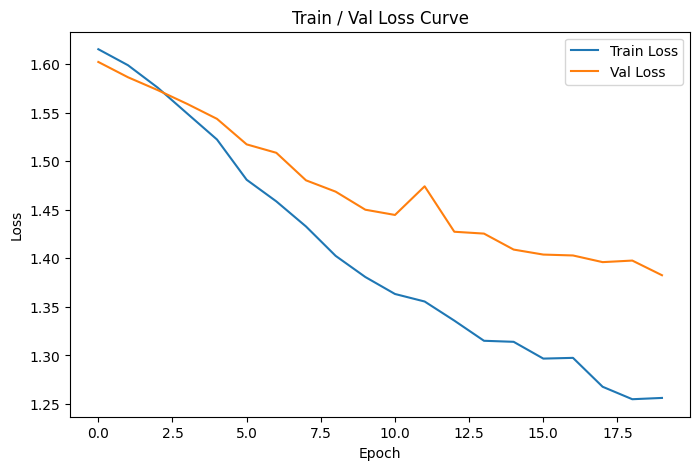

----------------------------------------
Test input shape: torch.Size([1, 6, 6000])
Test output shape: torch.Size([1, 5])


In [9]:
import h5py
import torch
import torch.nn as nn
import matplotlib
matplotlib.use('Agg')  # 非交互后端，避免 plt.show() 阻塞
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from TEST_DATASET import TrainDataset, TestDataset
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
from datetime import datetime
import shutil
import warnings
warnings.filterwarnings('ignore')

CLASSES = len(category_list)
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4

# -------------------------
# 数据
# -------------------------
train_ds = TrainDataset(str(INDEX_PATH_TRAIN))
val_ds = TrainDataset(str(INDEX_PATH_VAL))
test_ds = TestDataset(str(INDEX_PATH_TEST))

# 从真实样本自动读取输入尺寸，避免不同数据集维度不一致
sample_x, _ = train_ds[0]
CHANNELS, patch_size = sample_x.shape

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# -------------------------
# 模型、损失、优化器
# -------------------------
MODEL_NAME = "EEGNet"  # 可选: "SimpleLinear" / "SimpleMLP" / "EEGNet" / "EEGGRU"

if MODEL_NAME == "SimpleLinear":
    model = SimpleLinear(input_channels=CHANNELS, time_points=patch_size, num_classes=CLASSES)
elif MODEL_NAME == "SimpleMLP":
    model = SimpleMLP(input_channels=CHANNELS, time_points=patch_size, num_classes=CLASSES)
elif MODEL_NAME == "EEGNet":
    model = EEGNet(chans=CHANNELS, time_point=patch_size, num_classes=CLASSES)
elif MODEL_NAME == "EEGGRU":
    model = EEGGRU(chans=CHANNELS, num_classes=CLASSES)
else:
    raise ValueError(f"Unsupported MODEL_NAME: {MODEL_NAME}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(f"Model: {MODEL_NAME}")
print(f"Model input shape set to: (C={CHANNELS}, T={patch_size})")

# ================================================================
# 创建结构化输出目录: results/{DATA_NAME}/{MODEL_NAME}/{实验名}/
# ================================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# 自动编号：检查已经有多少个实验
exp_parent = RESULTS_DIR / DATA_NAME / MODEL_NAME
exp_parent.mkdir(parents=True, exist_ok=True)
existing = sorted([d.name for d in exp_parent.iterdir() if d.is_dir()])
next_num = 1
if existing:
    # 尝试从已有目录名中提取序号
    nums = []
    for d in existing:
        try:
            nums.append(int(d.split('_')[0]))
        except (ValueError, IndexError):
            pass
    if nums:
        next_num = max(nums) + 1

EXP_NAME = f"{next_num:03d}_{timestamp}_bs{BATCH_SIZE}_lr{LR}"
EXP_DIR = exp_parent / EXP_NAME
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experiment dir: {EXP_DIR}")

# 各结果文件路径
CONFIG_PATH = EXP_DIR / "config.json"
METRICS_PATH = EXP_DIR / "metrics.csv"
LOSS_CURVE_PATH = EXP_DIR / "loss_curve.png"
BEST_MODEL_PATH = EXP_DIR / "best_model.pt"
PREDICTIONS_PATH = EXP_DIR / "predictions.txt"
VAL_CM_PATH = EXP_DIR / "val_confusion_matrix.png"
CLASS_REPORT_PATH = EXP_DIR / "classification_report.csv"
FAILURE_CASES_PATH = EXP_DIR / "failure_cases.csv"

# ================================================================
# 保存实验配置
# ================================================================
config = {
    "dataset": DATA_NAME,
    "model": MODEL_NAME,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "optimizer": "Adam",
    "loss_fn": "CrossEntropyLoss",
    "num_classes": CLASSES,
    "channels": CHANNELS,
    "time_points": patch_size,
    "experiment_time": timestamp,
    "categories": category_list,
}
with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print(f"Config saved to: {CONFIG_PATH}")

# -------------------------
# 记录曲线
# -------------------------
train_losses = []
val_losses = []
val_accuracies = []

best_val_acc = -1.0

# -------------------------
# 训练循环
# -------------------------
for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_num = 0

    for data, label in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

    epoch_train_loss = train_loss_sum / train_num
    train_losses.append(epoch_train_loss)

    # ===== Val =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()
            all_val_preds.extend(val_pred.cpu().tolist())
            all_val_labels.extend(val_label.cpu().tolist())

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # 保存 best checkpoint
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': epoch_val_acc,
            'val_loss': epoch_val_loss,
            'config': config,
        }, BEST_MODEL_PATH)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

# -------------------------
# 保存 metrics.csv（每 epoch 指标）
# -------------------------
metrics_df = pd.DataFrame({
    "epoch": list(range(1, EPOCHS + 1)),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "val_accuracy": val_accuracies,
})
metrics_df.to_csv(METRICS_PATH, index=False)
print(f"Metrics saved to: {METRICS_PATH}")

# -------------------------
# 保存 loss_curve.png
# -------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, 'o-', label="Train Loss", linewidth=2, markersize=4)
plt.plot(range(1, EPOCHS + 1), val_losses, 's-', label="Val Loss", linewidth=2, markersize=4)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title(f"{DATA_NAME} / {MODEL_NAME} — Train / Val Loss Curve", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# 标注 best epoch
if best_val_acc > 0:
    plt.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5)
    plt.annotate(f'Best epoch={best_epoch}\nVal Acc={best_val_acc:.4f}',
                 xy=(best_epoch, val_losses[best_epoch - 1]),
                 xytext=(best_epoch + 1, val_losses[best_epoch - 1] + 0.05),
                 fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig(str(LOSS_CURVE_PATH), dpi=150, bbox_inches='tight')
plt.close()
print(f"Loss curve saved to: {LOSS_CURVE_PATH}")

# -------------------------
# 输出最终 val accuracy
# -------------------------
print("\n" + "-" * 50)
print(f"Best  Val Accuracy: {best_val_acc:.4f}  (epoch {best_epoch})")
print(f"Final Val Accuracy: {val_accuracies[-1]:.4f}")

# -------------------------
# 验证集详细评估：混淆矩阵 + 分类报告
# -------------------------
model.eval()
all_val_preds = []
all_val_labels = []
with torch.no_grad():
    for val_data, val_label in val_loader:
        val_output = model(val_data)
        val_pred = torch.argmax(val_output, dim=1)
        all_val_preds.extend(val_pred.cpu().tolist())
        all_val_labels.extend(val_label.cpu().tolist())

# 混淆矩阵
cm = confusion_matrix(all_val_labels, all_val_preds)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f"{DATA_NAME} / {MODEL_NAME} — Confusion Matrix (Val Set)", fontsize=14)
plt.colorbar(shrink=0.8)
tick_marks = np.arange(len(category_list))
plt.xticks(tick_marks, category_list, rotation=45, ha='right')
plt.yticks(tick_marks, category_list)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

# 在每个格子中显示数值
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig(str(VAL_CM_PATH), dpi=150, bbox_inches='tight')
plt.close()
print(f"Confusion matrix saved to: {VAL_CM_PATH}")

# 分类报告
report_dict = classification_report(all_val_labels, all_val_preds,
                                    target_names=category_list,
                                    output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(CLASS_REPORT_PATH, float_format='%.4f')
print(f"Classification report saved to: {CLASS_REPORT_PATH}")

print("\nClassification Report:")
print(classification_report(all_val_labels, all_val_preds,
                            target_names=category_list, zero_division=0))

# -------------------------
# 保存分错样本（Failure Cases）
# -------------------------
all_val_preds_arr = np.array(all_val_preds)
all_val_labels_arr = np.array(all_val_labels)
failure_mask = all_val_preds_arr != all_val_labels_arr

if failure_mask.sum() > 0:
    failure_indices = np.where(failure_mask)[0]
    failure_df = pd.DataFrame({
        "sample_index": failure_indices,
        "true_label": all_val_labels_arr[failure_indices],
        "true_category": [category_list[l] for l in all_val_labels_arr[failure_indices]],
        "predicted_label": all_val_preds_arr[failure_indices],
        "predicted_category": [category_list[l] for l in all_val_preds_arr[failure_indices]],
    })
    failure_df.to_csv(FAILURE_CASES_PATH, index=False)
    print(f"Failure cases ({len(failure_df)} samples) saved to: {FAILURE_CASES_PATH}")
else:
    print("No failure cases on validation set — model classifies all correctly!")

# -------------------------
# 追加到 experiments_summary.csv
# -------------------------
summary_path = RESULTS_DIR / "experiments_summary.csv"
summary_entry = {
    "experiment_name": EXP_NAME,
    "dataset": DATA_NAME,
    "model": MODEL_NAME,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "best_val_acc": f"{best_val_acc:.4f}",
    "final_val_acc": f"{val_accuracies[-1]:.4f}",
    "best_epoch": best_epoch,
    "num_params": sum(p.numel() for p in model.parameters()),
    "experiment_time": timestamp,
    "experiment_dir": str(EXP_DIR),
}
summary_entry_df = pd.DataFrame([summary_entry])

if summary_path.exists():
    existing_df = pd.read_csv(summary_path)
    combined = pd.concat([existing_df, summary_entry_df], ignore_index=True)
    combined.to_csv(summary_path, index=False)
else:
    summary_entry_df.to_csv(summary_path, index=False)
print(f"Experiment summary updated: {summary_path}")

# ================================================================
# 保存 test 预测标签（也在本格完成，不再依赖 Cell 16）
# ================================================================
model.eval()
# 加载最佳模型权重进行测试
if BEST_MODEL_PATH.exists():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']} for test inference")

all_test_labels = []
with torch.no_grad():
    for test_data in test_loader:
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

with open(PREDICTIONS_PATH, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")
print(f"Saved {len(all_test_labels)} test predictions to: {PREDICTIONS_PATH}")

# 同时保持对旧路径 predictions/ 的兼容（可选）
legacy_pred_path = RESULTS_DIR / "predictions" / f"{DATA_NAME}_{MODEL_NAME}.txt"
legacy_pred_path.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(str(PREDICTIONS_PATH), str(legacy_pred_path))
print(f"Also copied to legacy path: {legacy_pred_path}")

# ================================================================
# 打印最终实验摘要
# ================================================================
print("\n" + "=" * 55)
print(f"Experiment Summary: {EXP_NAME}")
print("=" * 55)
print(f"  Dataset:     {DATA_NAME}")
print(f"  Model:       {MODEL_NAME}")
print(f"  Best Val Acc: {best_val_acc:.4f} (epoch {best_epoch})")
print(f"  Test preds:  {len(all_test_labels)} samples → {PREDICTIONS_PATH.name}")
print(f"  All outputs: {EXP_DIR}")
print("=" * 55)

# 展示 loss 曲线（最终显示一次）
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, 'o-', label="Train Loss", linewidth=2, markersize=4)
plt.plot(range(1, EPOCHS + 1), val_losses, 's-', label="Val Loss", linewidth=2, markersize=4)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title(f"{DATA_NAME} / {MODEL_NAME} — Train / Val Loss Curve", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [10]:
# -------------------------
# 测试集预测已在 Cell 14 中完成并保存
# 本格仅做提醒，避免重复推理
# -------------------------
print("=" * 55)
print("Test predictions already saved in Cell 14 during training.")
print(f"Check: {EXP_DIR / 'predictions.txt'}")
print("=" * 55)


Saved 1945 labels to: c:\Users\29722\Desktop\新建文件夹\course project\SLEEP\SLEEP_EEGNet.txt
